<a href="https://colab.research.google.com/github/cosmyyyyyyyy12/AgriPredict-Linear-Regression-Pipeline/blob/main/AgriPredict_Linear_Regression_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EDA


In [247]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [248]:
df = pd.read_csv("https://raw.githubusercontent.com/cosmyyyyyyyy12/AgriPredict-Linear-Regression-Pipeline/refs/heads/main/yield_df.csv")

In [249]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [250]:
df.shape

(28242, 8)

In [251]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


In [252]:
df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [253]:
df.isnull().sum()

,0
Unnamed: 0,0
Area,0
Item,0
Year,0
hg/ha_yield,0
average_rain_fall_mm_per_year,0
pesticides_tonnes,0
avg_temp,0


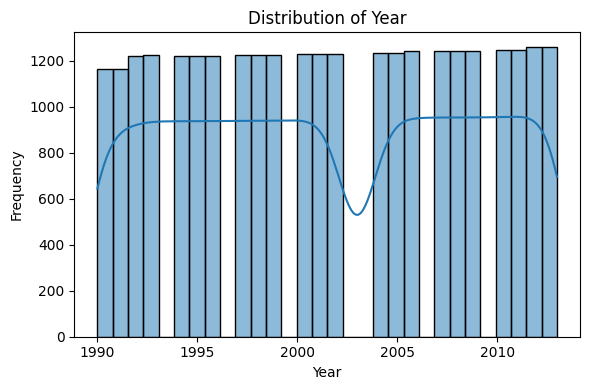

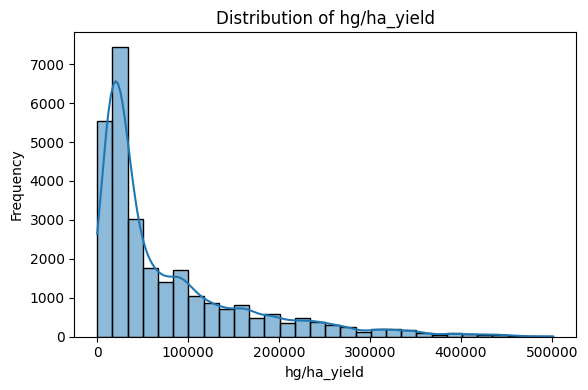

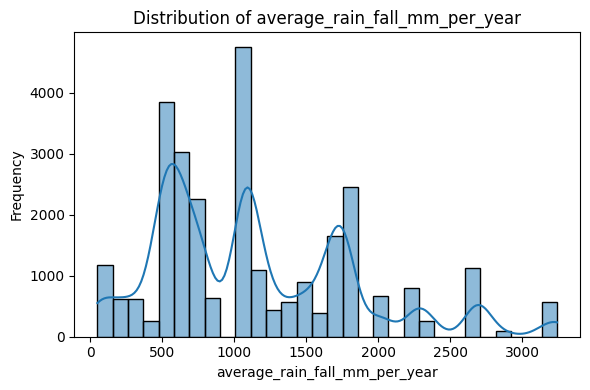

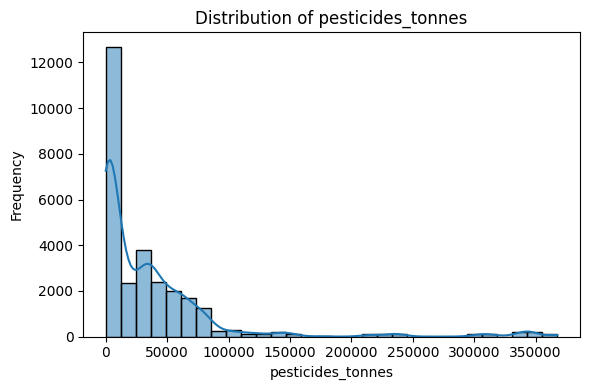

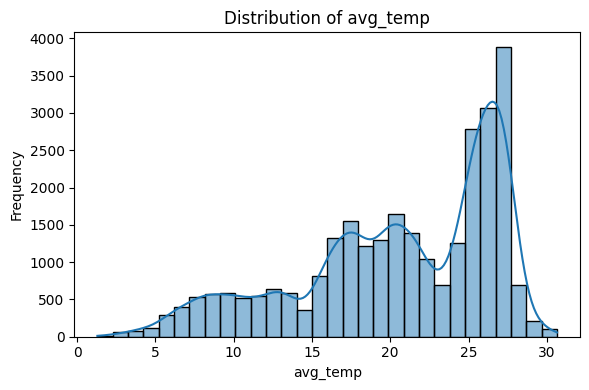

In [254]:
numerical_columns = ['Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde = True , bins = 30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


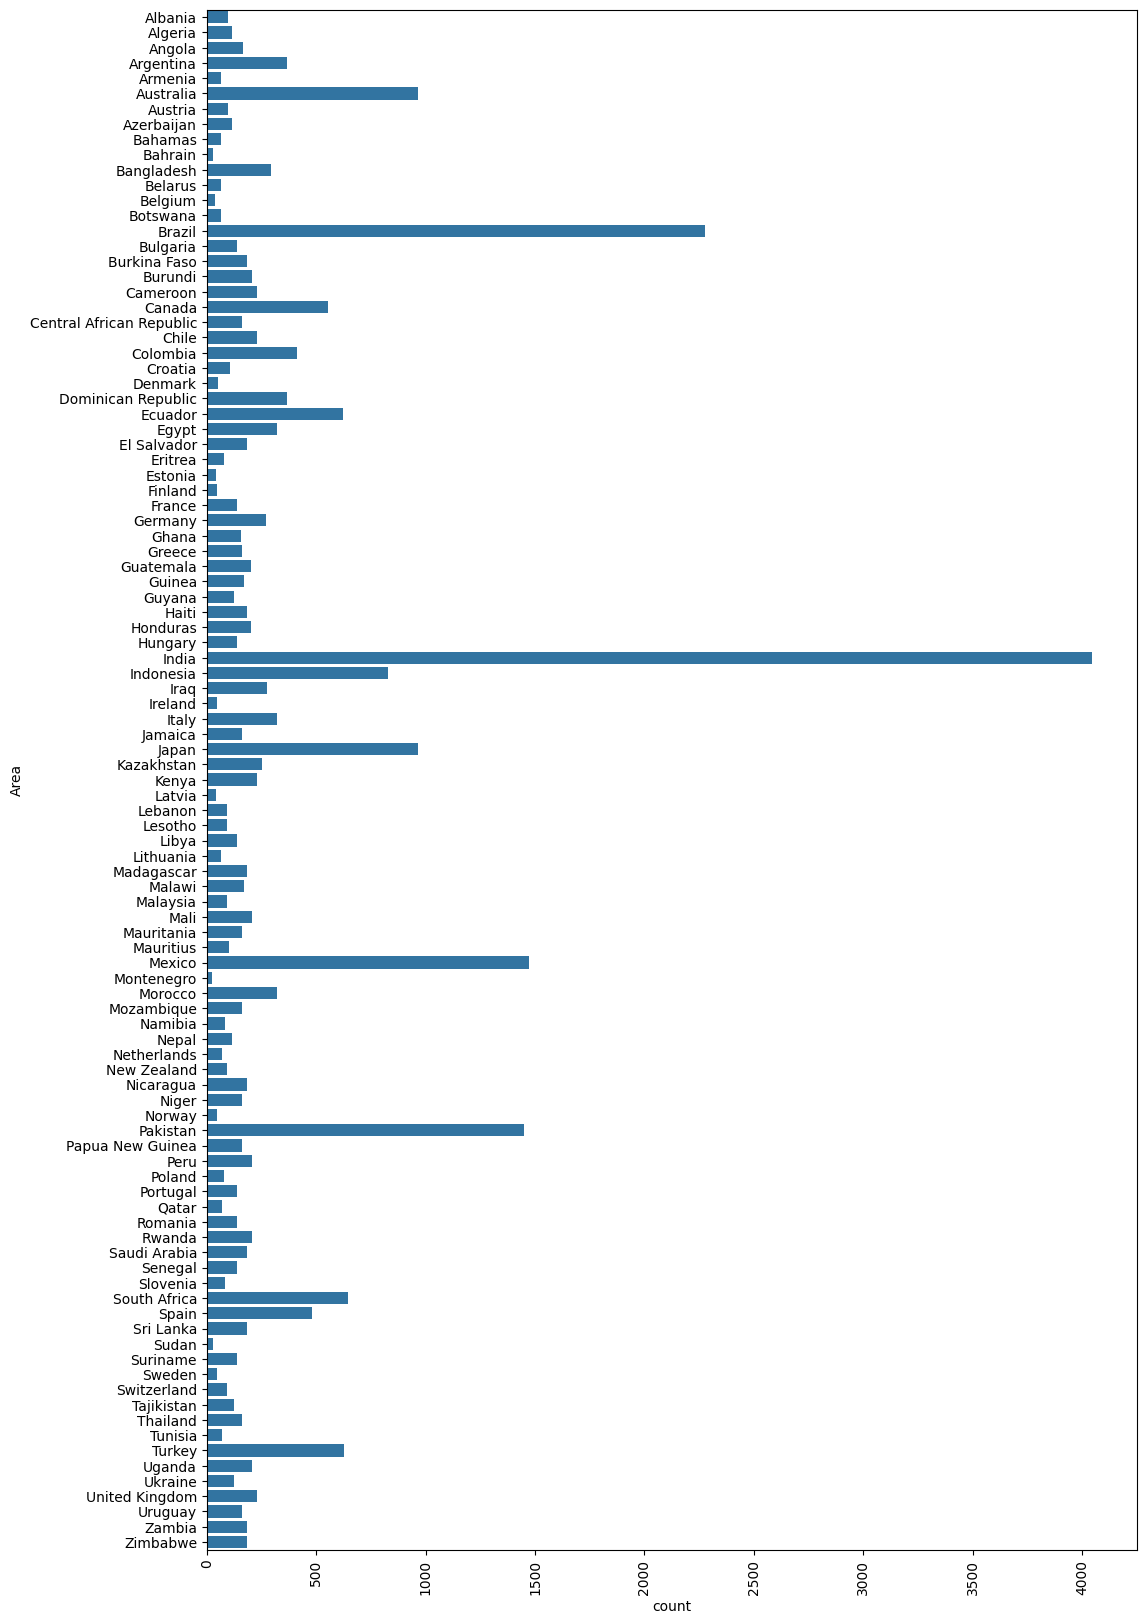

In [255]:
plt.figure(figsize=(12, 20))
sns.countplot(data=df, y='Area')
plt.xticks(rotation=90)
plt.show()

In [256]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [257]:
df.duplicated().sum()

np.int64(0)

In [258]:
df.drop_duplicates(inplace=True)

In [259]:
df.duplicated().sum()

np.int64(0)

In [260]:
df.shape

(28242, 8)

In [261]:
corr = df.corr(numeric_only=True)
corr

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
Unnamed: 0,1.000000,0.043850,0.013395,-0.228755,-0.316017,-0.051584
Year,0.043850,1.000000,0.091630,-0.003798,0.140930,0.014409
hg/ha_yield,0.013395,0.091630,1.000000,0.000962,0.064085,-0.114777
average_rain_fall_mm_per_year,-0.228755,-0.003798,0.000962,1.000000,0.180984,0.313040
pesticides_tonnes,-0.316017,0.140930,0.064085,0.180984,1.000000,0.030946
avg_temp,-0.051584,0.014409,-0.114777,0.313040,0.030946,1.000000


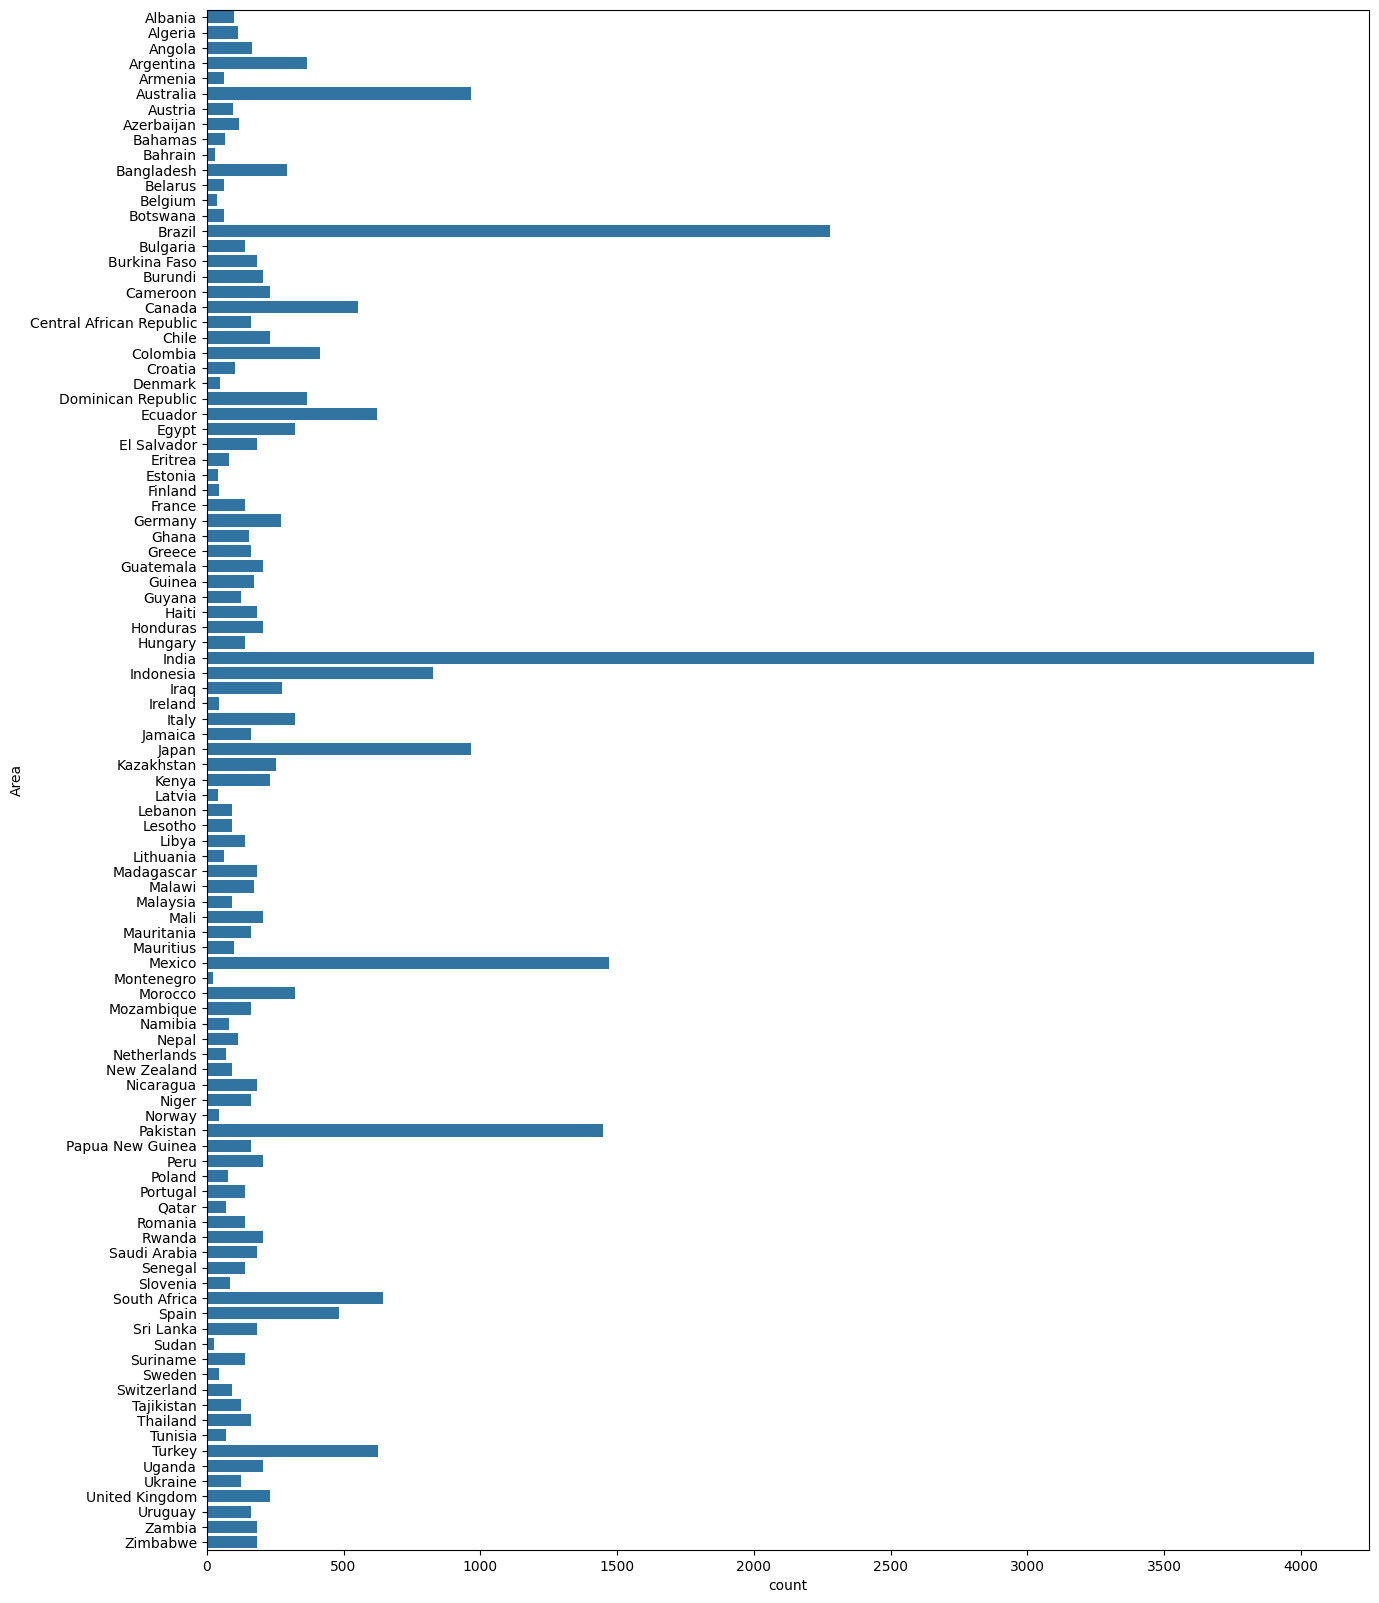

In [262]:
plt.figure(figsize=(15,20))
sns.countplot(y = df['Area'])
plt.show()

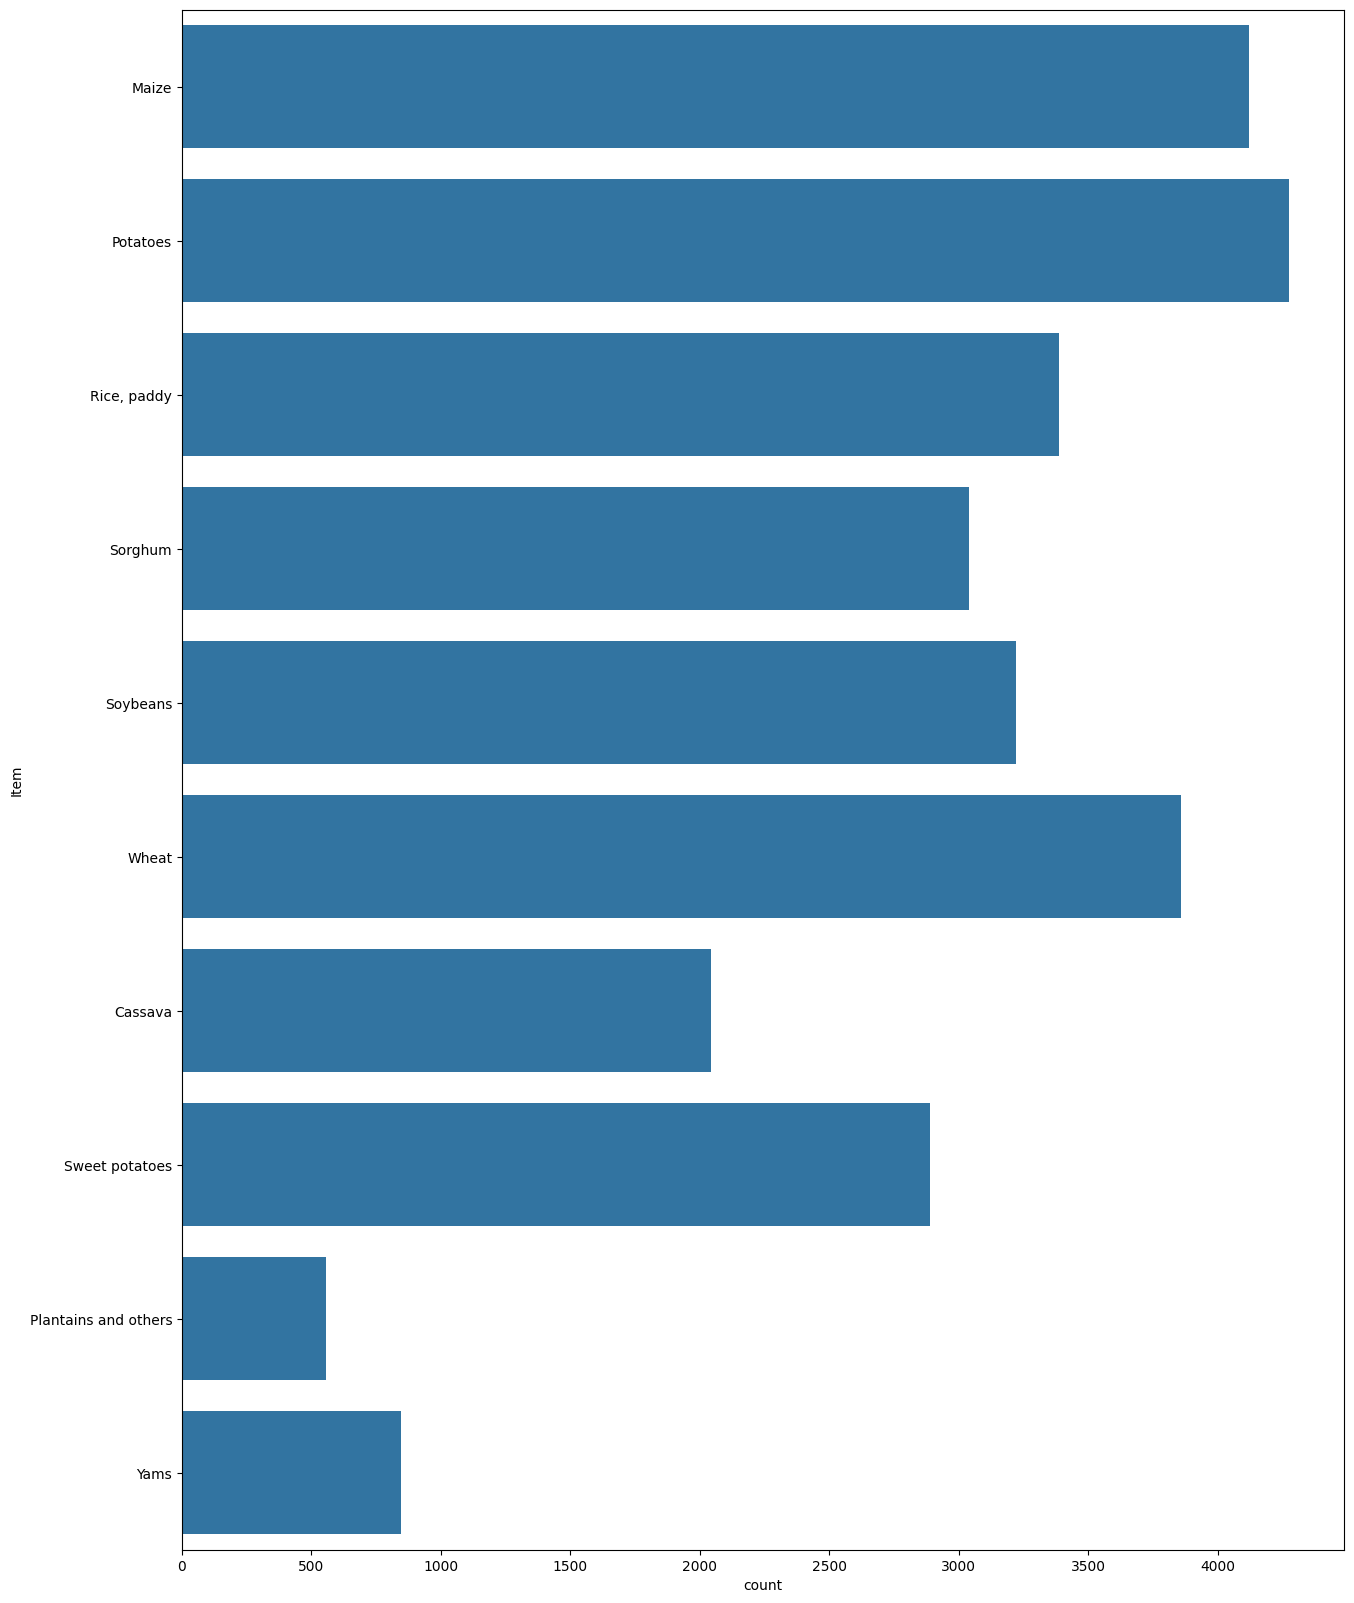

In [263]:
plt.figure(figsize=(15,20))
sns.countplot(y = df['Item'])
plt.show()

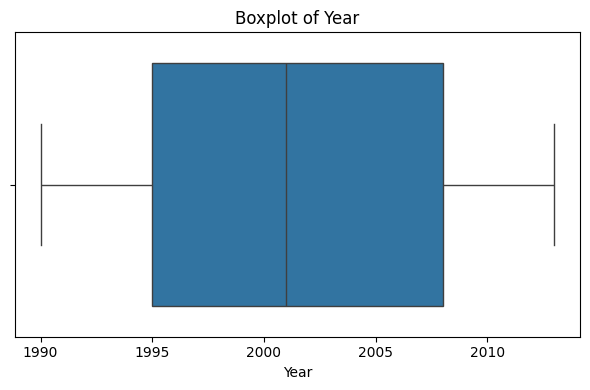

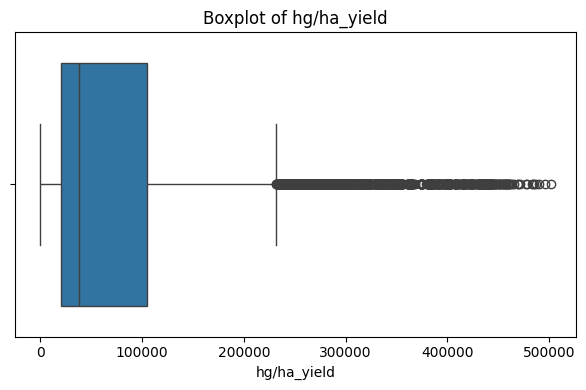

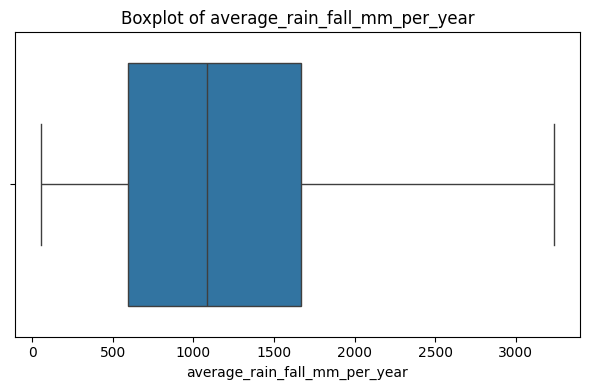

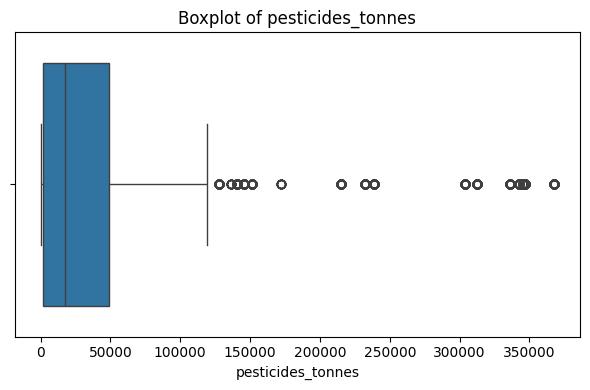

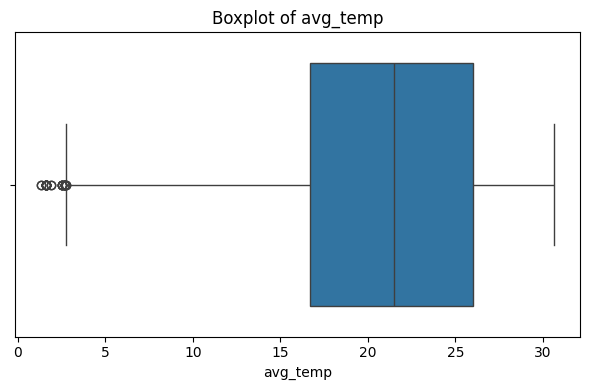

In [264]:
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

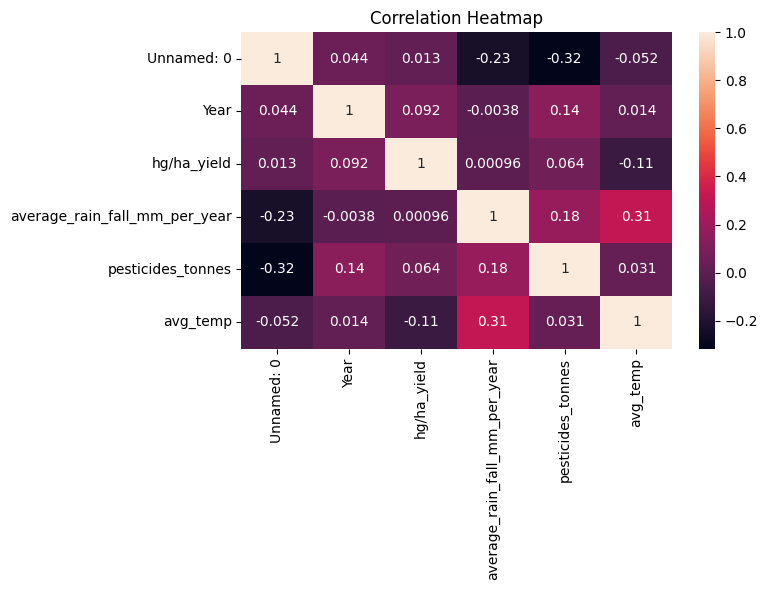

In [265]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [266]:
# DATA Cleaning and Preprocessing

# DATA Cleaning and Preprocessing

In [267]:
df_cleaned = df.copy()


In [268]:
df_cleaned.drop_duplicates(inplace=True)

In [269]:
df_cleaned.shape

(28242, 8)

In [270]:
print("Missing Values:\n", df_cleaned.isnull().sum())

Missing Values:
 Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [271]:
print("\nData Types:\n", df_cleaned.dtypes)


Data Types:
 Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object


In [272]:
df_cleaned['Area'].value_counts()

,count
Area,
India,4048
Brazil,2277
Mexico,1472
Pakistan,1449
Australia,966
...,...
Latvia,42
Belgium,39
Bahrain,29


In [273]:
df_cleaned['Item'].value_counts()

,count
Item,
Potatoes,4276
Maize,4121
Wheat,3857
"Rice, paddy",3388
Soybeans,3223
Sorghum,3039
Sweet potatoes,2890
Cassava,2045
Yams,847


In [274]:
df_cleaned = df.drop('Unnamed: 0', axis=1)

In [275]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['Area'], drop_first=True)

In [276]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['Item'], drop_first=True)

In [277]:
df_cleaned = df_cleaned.astype(int)

In [278]:
df_cleaned.head()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area_Algeria,Area_Angola,Area_Argentina,Area_Armenia,Area_Australia,...,Area_Zimbabwe,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,1990,36613,1485,121,16,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,1990,66667,1485,121,16,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,1990,23333,1485,121,16,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,1990,12500,1485,121,16,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1990,7000,1485,121,16,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


# Feature Engineering and Extraction

In [284]:
from sklearn.preprocessing import StandardScaler
cols_to_scale = ['Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
scaler = StandardScaler()
df_cleaned[cols_to_scale] = scaler.fit_transform(df_cleaned[cols_to_scale])

In [285]:
df_cleaned.head()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area_Algeria,Area_Angola,Area_Argentina,Area_Armenia,Area_Australia,...,Area_Zimbabwe,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,-1.637075,-0.476020,0.473294,-0.616361,-0.64046,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,-1.637075,-0.122257,0.473294,-0.616361,-0.64046,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,-1.637075,-0.632338,0.473294,-0.616361,-0.64046,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,-1.637075,-0.759852,0.473294,-0.616361,-0.64046,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,-1.637075,-0.824592,0.473294,-0.616361,-0.64046,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [288]:
df_cleaned.columns

Index(['Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp', 'Area_Algeria', 'Area_Angola',
       'Area_Argentina', 'Area_Armenia', 'Area_Australia',
       ...
       'Area_Zimbabwe', 'Item_Maize', 'Item_Plantains and others',
       'Item_Potatoes', 'Item_Rice, paddy', 'Item_Sorghum', 'Item_Soybeans',
       'Item_Sweet potatoes', 'Item_Wheat', 'Item_Yams'],
      dtype='object', length=114)

In [289]:

from scipy.stats import pearsonr
selected_features = [
    'Year',
    'average_rain_fall_mm_per_year',
    'pesticides_tonnes',
    'avg_temp',
    'Area_Algeria',
    'Area_Angola',
    'Area_Argentina',
    'Area_Armenia',
    'Area_Australia',
    'Area_Austria',
    'Area_Azerbaijan',
    'Area_Bahamas',
    'Area_Bahrain',
    'Area_Bangladesh',
    'Area_Belarus',
    'Area_Belgium',
    'Area_Botswana',
    'Area_Brazil',
    'Area_Bulgaria'
]
correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['hg/ha_yield'])[0]
    for feature in selected_features
}

# Convert to DataFrame for display
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])

# Show the results
correlation_df.sort_values(by='Pearson Correlation', ascending=False)


,Feature,Pearson Correlation
0,Year,0.091630
8,Area_Australia,0.079521
2,pesticides_tonnes,0.064085
15,Area_Belgium,0.061025
12,Area_Bahrain,0.028751
9,Area_Austria,0.024742
6,Area_Argentina,0.016570
1,average_rain_fall_mm_per_year,0.000962
14,Area_Belarus,-0.001321
7,Area_Armenia,-0.002918


In [291]:
cat_features = [
    'Area_Algeria',
    'Area_Angola',
    'Area_Argentina',
    'Area_Armenia',
    'Area_Australia',
    'Area_Austria',
    'Area_Azerbaijan',
    'Area_Bahamas',
    'Area_Bahrain',
    'Area_Bangladesh',
    'Area_Belarus',
    'Area_Belgium',
    'Area_Botswana',
    'Area_Brazil',
    'Area_Bulgaria'
]

In [292]:
from scipy.stats import chi2_contingency
import pandas as pd

# Define significance level
alpha = 0.05

# Bin the target variable
df_cleaned['yield_bin'] = pd.qcut(df_cleaned['hg/ha_yield'], q=4, labels=False)

# Run Chi-Square test
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['yield_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

# Convert to DataFrame
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df


,chi2_statistic,p_value,Decision
Area_Brazil,213.763997,0.0,Reject Null (Keep Feature)
Area_Botswana,155.460893,0.0,Reject Null (Keep Feature)
Area_Argentina,134.442288,0.0,Reject Null (Keep Feature)
Area_Angola,124.815427,0.0,Reject Null (Keep Feature)
Area_Bahrain,65.544427,0.0,Reject Null (Keep Feature)
Area_Belgium,43.227347,0.0,Reject Null (Keep Feature)
Area_Austria,38.26623,0.0,Reject Null (Keep Feature)
Area_Bangladesh,31.867158,0.000001,Reject Null (Keep Feature)
Area_Algeria,25.245167,0.000014,Reject Null (Keep Feature)
Area_Australia,24.310396,0.000022,Reject Null (Keep Feature)


In [295]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X = df_cleaned.drop('hg/ha_yield', axis=1)
y = df_cleaned['hg/ha_yield']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [296]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [298]:
y_pred = model.predict(X_test)

In [299]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
r2

0.7811616891703579

In [300]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1- r2) * (n-1) / (n - p - 1))
adjusted_r2

0.7766536357849985